In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib import image
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon
from matplotlib.patches import Rectangle
import numpy as np
from collections import Counter
from scipy.spatial import cKDTree as KDT
from astropy.table import Column, Table
import itertools
import copy
import scipy.signal
from scipy.spatial import distance
import math
import sys
import pdb
import pickle as pickle
from astropy.convolution import convolve, Gaussian2DKernel
import astropy.coordinates as coord
import astropy.units as u
from astropy.io import ascii
import mpl_scatter_density
from scipy.stats import gaussian_kde, kde
from spisea import synthetic, evolution, atmospheres, reddening, ifmr
from spisea.imf import imf, multiplicity
import pdb
import pylab as py
from flystar import match, transforms, plots, align
from flystar import starlists
from flystar.starlists import StarList
from flystar.startables import StarTable
from astropy.table import Table, Column, vstack
import flystar
import datetime
import copy
import os
import pdb
import time
import warnings
from astropy.utils.exceptions import AstropyUserWarning
from numpy.polynomial.polynomial import polyfit
from astropy.io import fits
from astropy.table import * 

In [2]:
fits_image_filename ='catalogs/dr2/jwst_init_NRCB.fits'
t = Table.read(fits_image_filename, format='fits')

In [3]:
def get_all_filts(t):
    """
    Helper function to get filts in a catalog, regardless of
    masking
    """
    nepochs = len(t['filt'][0])

    # Loop through each time entry and get year
    # from a non-masked source
    filt_arr = []
    for ii in range(nepochs):
        filt_col = t['filt'][:,ii]

        good = np.where(t['x'][:,ii].mask == False)[0]
        if len(good) > 0:
            filt_arr.append(t['filt'][good[0],ii])
        else:
            filt_arr.append(np.nan)
       

    filt_arr = np.array(filt_arr)
   
    return filt_arr

def get_all_dets(t): 
    """
    Helper function to get detectors in a catalog, regardless of
    masking
    """
    nepochs = len(t['det'][0])

    # Loop through each time entry and get year
    # from a non-masked source
    det_arr = []
    for ii in range(nepochs):
        det_col = t['det'][:,ii]

        good = np.where(t['x'][:,ii].mask == False)[0]
        if len(good) > 0:
            det_arr.append(t['det'][good[0],ii])
        else:
            det_arr.append(np.nan)

    det_arr = np.array(det_arr)
   
    return det_arr

def get_matches(t, filt1, det1, filt2, det2): 
    filt = get_all_filts(t)
    det = get_all_dets(t)

    idx1 = np.where( (filt == filt1) & (det == det1) ) 
    idx2 = np.where( (filt == filt2) & (det == det2) ) 

    filt_1 = t['m_orig'][:,idx1]
    filt_2 = t['m_orig'][:,idx2]

    filt_1me = t['me_orig'][:,idx1]
    filt_2me = t['me_orig'][:,idx2]
    
    good = np.where( (filt_1.mask == False) & (filt_2.mask == False) )
    m_filt1_match = filt_1[good]
    m_filt2_match = filt_2[good]
    me_filt1_match = filt_1me[good]
    me_filt2_match = filt_2me[good]

    return m_filt1_match, m_filt2_match, me_filt1_match, me_filt2_match

In [4]:
# All NRCBs between F212N and F115W
N1_f115w_vf212n, N1_f212n_vf115w, N1_f115w_vf212n_me, N1_f212n_vf115w_me = get_matches(t, 'F115W', 'NRCB1', 'F212N', 'NRCB1')
N2_f115w_vf212n, N2_f212n_vf115w, N2_f115w_vf212n_me, N2_f212n_vf115w_me = get_matches(t, 'F115W', 'NRCB2', 'F212N', 'NRCB2')
N3_f115w_vf212n, N3_f212n_vf115w, N3_f115w_vf212n_me, N3_f212n_vf115w_me = get_matches(t, 'F115W', 'NRCB3', 'F212N', 'NRCB3')
N4_f115w_vf212n, N4_f212n_vf115w, N4_f115w_vf212n_me, N4_f212n_vf115w_me = get_matches(t, 'F115W', 'NRCB4', 'F212N', 'NRCB4')

# All NRCB1-4 F212N vs. NRCB5 F323N and F405N
N1_f212n_vN5_f323n, N5_f323n_vN1_f212n, N1_f212n_vN5_f323n_me, N5_f323n_vN1_f212n_me = get_matches(t, 'F212N', 'NRCB1', 'F323N', 'NRCB5')
N2_f212n_vN5_f323n, N5_f323n_vN2_f212n, N2_f212n_vN5_f323n_me, N5_f323n_vN1_f212n_me = get_matches(t, 'F212N', 'NRCB2', 'F323N', 'NRCB5')
N3_f212n_vN5_f323n, N5_f323n_vN3_f212n, N3_f212n_vN5_f323n_me, N5_f323n_vN1_f212n_me = get_matches(t, 'F212N', 'NRCB3', 'F323N', 'NRCB5')
N4_f212n_vN5_f323n, N5_f323n_vN4_f212n, N4_f212n_vN5_f323n_me, N5_f323n_vN1_f212n_me = get_matches(t, 'F212N', 'NRCB4', 'F323N', 'NRCB5')

N1_f212n_vN5_f405n, N5_f405n_vN1_f212n, N1_f212n_vN5_f405n_me, N5_f405n_vN1_f212n_me = get_matches(t, 'F212N', 'NRCB1', 'F405N', 'NRCB5')
N2_f212n_vN5_f405n, N5_f405n_vN2_f212n, N2_f212n_vN5_f405n_me, N5_f405n_vN1_f212n_me = get_matches(t, 'F212N', 'NRCB2', 'F405N', 'NRCB5')
N3_f212n_vN5_f405n, N5_f405n_vN3_f212n, N3_f212n_vN5_f405n_me, N5_f405n_vN1_f212n_me = get_matches(t, 'F212N', 'NRCB3', 'F405N', 'NRCB5')
N4_f212n_vN5_f405n, N5_f405n_vN4_f212n, N4_f212n_vN5_f405n_me, N5_f405n_vN1_f212n_me = get_matches(t, 'F212N', 'NRCB4', 'F405N', 'NRCB5')

N1_f115w_vf212n += 25.92
N2_f115w_vf212n += 25.95
N3_f115w_vf212n += 25.95
N4_f115w_vf212n += 26.09

N1_f212n_vf115w += 22.12
N2_f212n_vf115w += 22.15
N3_f212n_vf115w += 22.15 
N4_f212n_vf115w += 22.23
N1_f212n_vN5_f323n += 22.12
N2_f212n_vN5_f323n += 22.15
N3_f212n_vN5_f323n += 22.15
N4_f212n_vN5_f323n += 22.23
N1_f212n_vN5_f405n += 22.12
N2_f212n_vN5_f405n += 22.15
N3_f212n_vN5_f405n += 22.15
N4_f212n_vN5_f405n += 22.23

N5_f323n_vN1_f212n += 21.14 
N5_f323n_vN2_f212n += 21.14 
N5_f323n_vN3_f212n += 21.14
N5_f323n_vN4_f212n += 21.14

N5_f405n_vN1_f212n += 20.91
N5_f405n_vN2_f212n += 20.91
N5_f405n_vN3_f212n += 20.91
N5_f405n_vN4_f212n += 20.91

## NRCB1 -- F115W - F212N vs. F212N CMD

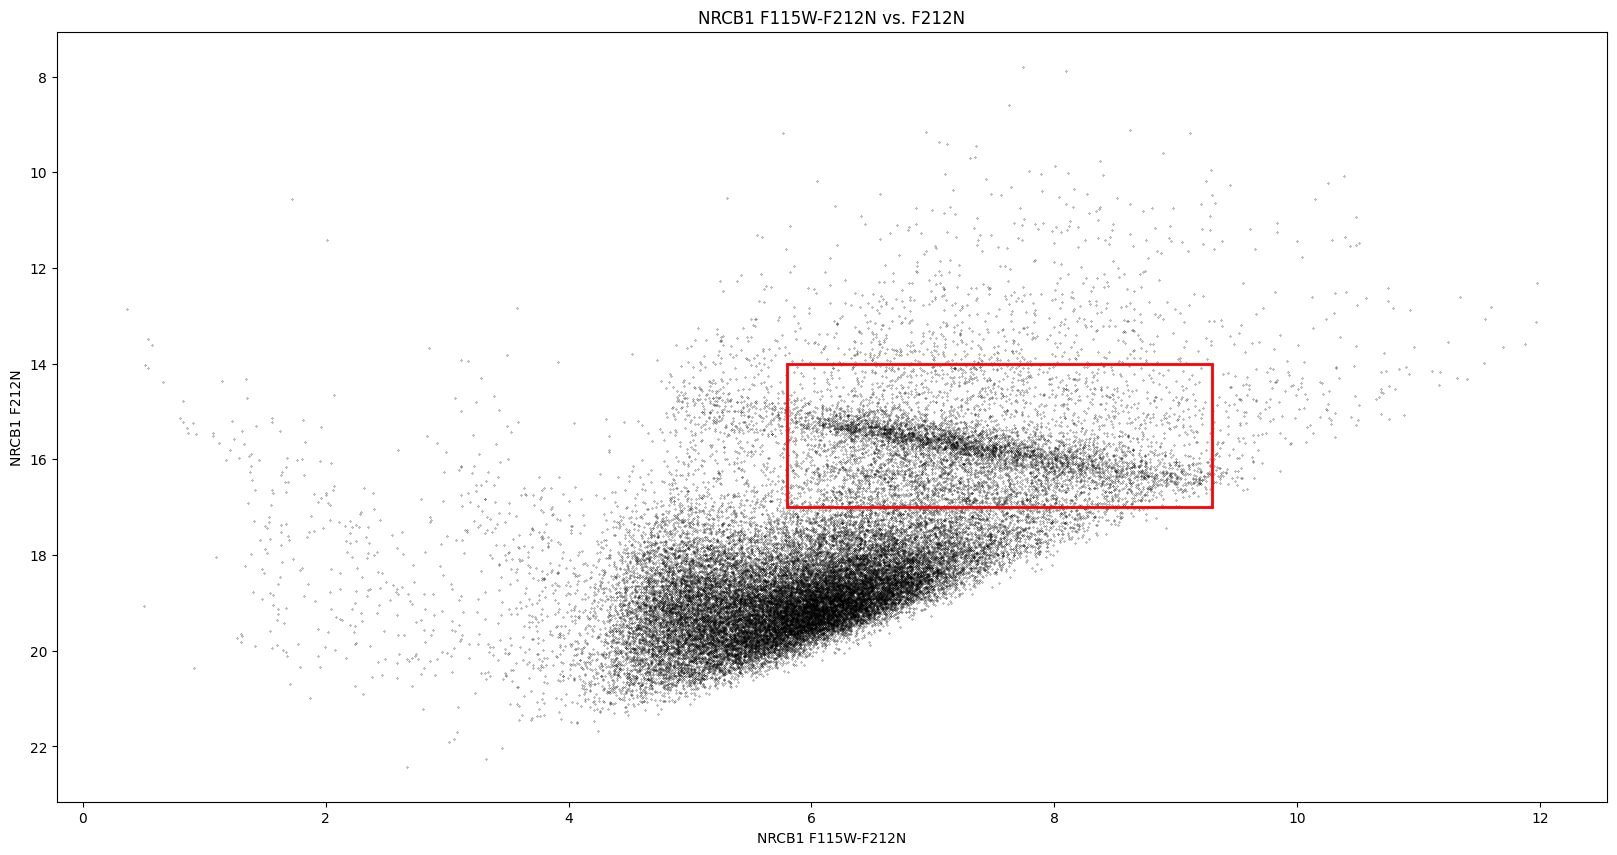

In [5]:
fig, axis = plt.subplots(1,1, figsize = (20, 10))

plt.scatter(np.subtract(N1_f115w_vf212n, N1_f212n_vf115w), N1_f212n_vf115w, c = 'k', s = 0.05)
plt.gca().invert_yaxis()
plt.xlabel('NRCB1 F115W-F212N')
plt.ylabel('NRCB1 F212N')
plt.title('NRCB1 F115W-F212N vs. F212N')

cutoff = Rectangle((5.8, 14), 3.5, 3, facecolor = (1, 0, 0, 0), lw = 2, ec = (1, 0, 0, 1))
axis.add_patch(cutoff)

In [6]:
def divide_rect(n, lower_left, width, height):
    x, y = lower_left
    dx = width / n
    segment_height = height
    xbins = []
    segments = []
    
    for i in range(n):
        segments.append(Rectangle((x + i * dx, y), dx, segment_height, 
                                  facecolor = (1, 0, 0, 0), lw = 2, ec = (1, 0, 0, 1)
                                 )
                       )
        xbins.append([x + i * dx, x + i * dx + dx])
        
    return segments, xbins

def extract_idxs(filt1, filt2, filty, xbins, y_range): 
    x = np.subtract(filt1, filt2)
    y = filty
    mag_binned = []

    for i in range(len(xbins)): 
        good = np.where(x >= xbins[i][0] and x <= xbins[i][1] and y >= y_range[0])

def Gauss(x, A, B): 
    y = A*np.exp(-1*B*x**2) 
    return y 

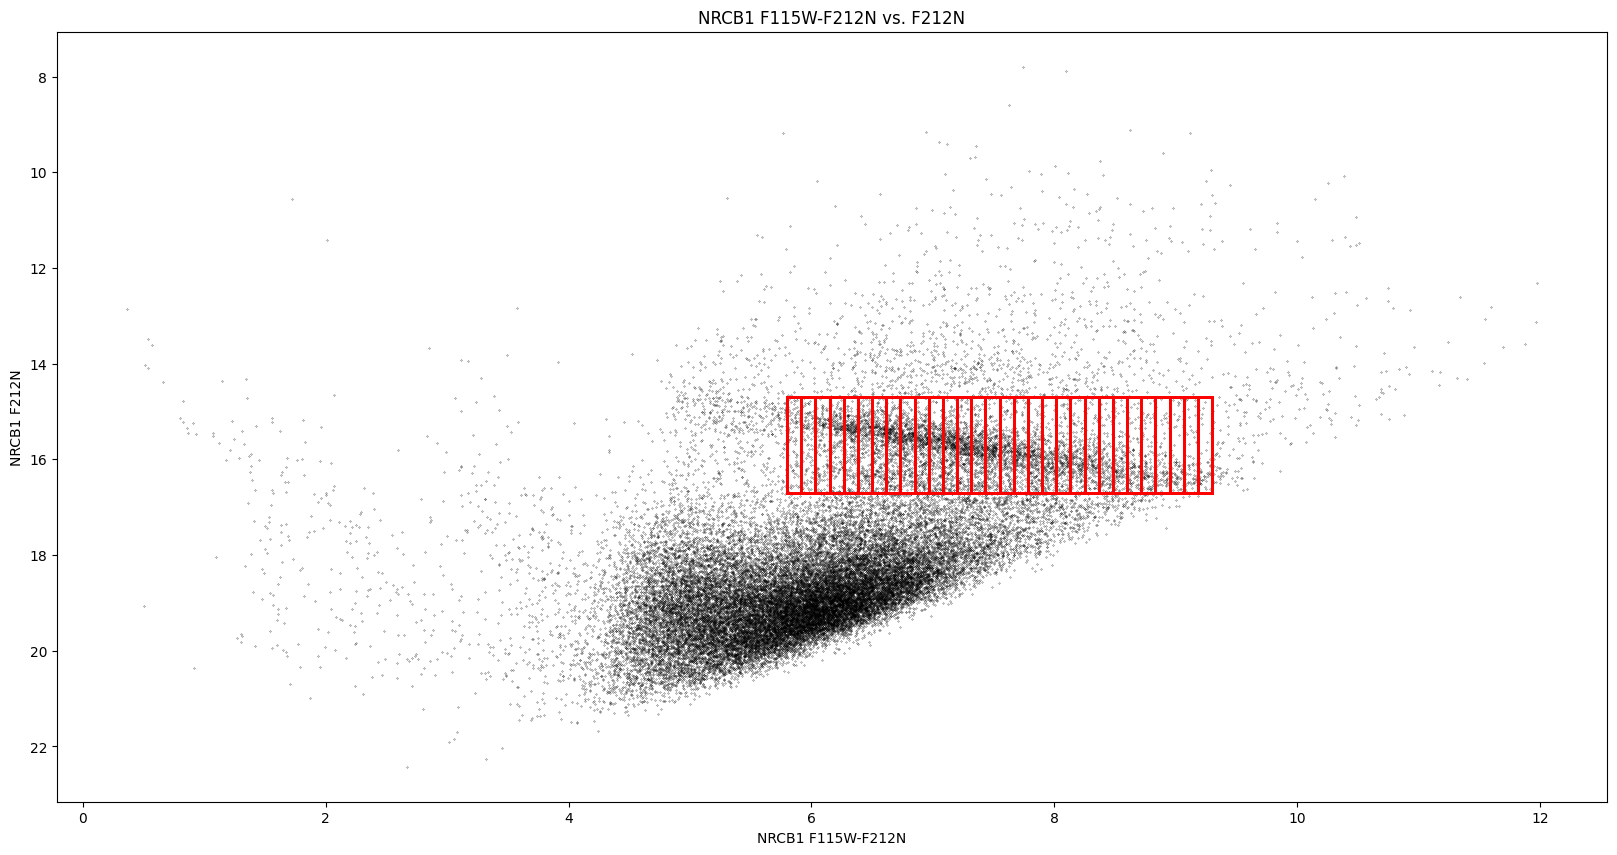

In [7]:
n = 30 # Number of segments

segments, xbins = divide_rect(n, (5.8, 14.7), 3.5, 2)

fig, axis = plt.subplots(1,1, figsize = (20, 10))

plt.scatter(np.subtract(N1_f115w_vf212n, N1_f212n_vf115w), N1_f212n_vf115w, c = 'k', s = 0.05)
plt.gca().invert_yaxis()
plt.xlabel('NRCB1 F115W-F212N')
plt.ylabel('NRCB1 F212N')
plt.title('NRCB1 F115W-F212N vs. F212N')

cutoff = Rectangle((5.8, 14.7), 3.5, 2, facecolor = (1, 0, 0, 0), lw = 2, ec = (1, 0, 0, 1))
axis.add_patch(cutoff)

for segment in segments: 
    axis.add_patch(segment)

plt.savefig('test.png')

15.55528937182825
0.5580302589429729
15.60129094399403
0.5497392442417286
15.635427014688137
0.5282014370839644
15.610795058335581
0.5212205646639394
15.64715391145451
0.48612886279759304
15.631668730810066
0.5255523563972215
15.669462850469754
0.49239906842123493
15.674140701998377
0.4641833086773041
15.692266712788962
0.4314418373764614
15.783261979811426
0.4691844086749497
15.782154431218085
0.43131217346348744
15.781078805694737
0.41882693201399773
15.802043121791266
0.42481693434128587
15.839097413731661
0.44048841774822717
15.86315527250313
0.39718776535779243
15.890310113346372
0.42657480840996087
15.886206310723436
0.4080257343652861
15.943883028859828
0.40800865287464794
16.04097532015243
0.39582731942629223
15.973397133251524
0.4271152757376699
15.993664445465615
0.4228128845688453
15.970407791155866
0.4086167008318983
16.04928790941744
0.4822098609052506
15.996640985321402
0.4801054039251426
16.03305407011473
0.4726293497078309
16.06758476873219
0.4981853745055484
16.0235497

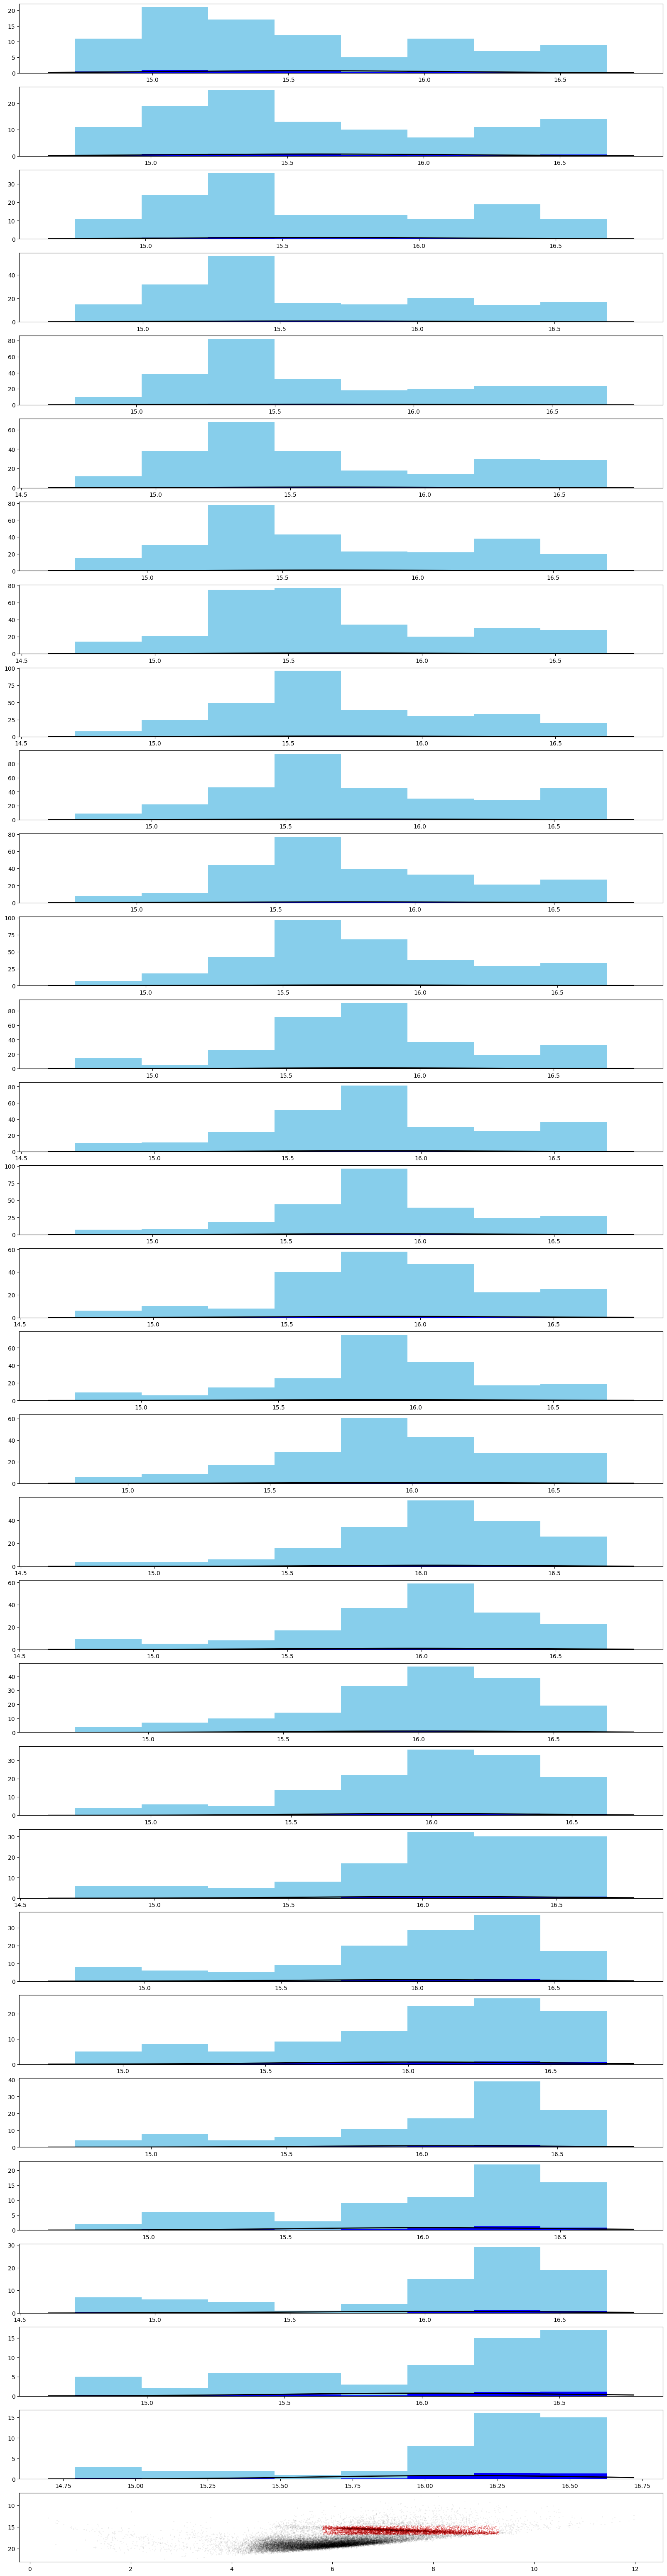

In [19]:
from scipy.stats import norm

filt1 = N1_f115w_vf212n
filt2 = N1_f212n_vf115w
filty = N1_f212n_vf115w

x = np.subtract(filt1, filt2)
y = filty
mag_idxs = []
mu_arr = []

for i in range(len(xbins)): 
    good_xlower = np.where(x >= xbins[i][0])
    good_xupper = np.where(x <= xbins[i][1])
    good_ylower = np.where(y >= 14.7)
    good_yupper = np.where(y <= 16.7)
    good_x = np.intersect1d(good_xlower, good_xupper)
    good_y = np.intersect1d(good_ylower, good_yupper)
    good = np.intersect1d(good_x, good_y)

    mag_idxs.append([good])

filt1 = []
filt2 = []

fig, axis = plt.subplots(n+1, 1, figsize = (20, 80))

for i in range(len(mag_idxs)):
    for j in mag_idxs[i]: 
        filt1.append(N1_f115w_vf212n[j])
        filt2.append(N1_f212n_vf115w[j])

        axis[i].hist(filt2, bins=8, color='skyblue')

        axis[n].scatter(np.subtract(filt1, filt2), filt2, c = 'r', s = 0.05)

        data = filt2
        
        mu, std = norm.fit(data) 
        mu_arr.append(mu)
        print(mu)
        print(std)
 
        # Plot the histogram.
        axis[i].hist(data, bins=8, density = True, color='blue')
        
        # Plot the PDF.
        xmin, xmax = axis[i].get_xlim()
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, mu, std)
        
        axis[i].plot(x, p, 'k', linewidth=2)

        filt1 = []
        filt2 = []

axis[n].scatter(np.subtract(N1_f115w_vf212n, N1_f212n_vf115w), N1_f212n_vf115w, c = 'k', s = 0.01, alpha = 0.5)
axis[n].invert_yaxis()
plt.savefig('test2.png')

In [1]:
cutoff_idx = []

for i in range(len(xbins)): 
    if xbins[i][0] > 7.8: 
        cutoff_idx.append(i)

cutoff_idx = cutoff_idx[0]

xbins_avg = []

for i in xbins: 
    xbins_avg.append((i[0] + i[0])/2)

fig, axis = plt.subplots(1, 1, figsize = (20, 10))

plt.scatter(xbins_avg, mu_arr, c = 'k', s = 5)
plt.gca().invert_yaxis()

b, m1 = polyfit(xbins_avg[0:cutoff_idx], mu_arr[0:cutoff_idx], 1)

plt.plot(xbins_avg[0:cutoff_idx], b + m1 * np.array(xbins_avg[0:cutoff_idx]), '-')


b, m2 = polyfit(xbins_avg[cutoff_idx:len(xbins)], mu_arr[cutoff_idx:len(xbins)], 1)

plt.plot(xbins_avg[cutoff_idx:len(xbins)], b + m2 * np.array(xbins_avg[cutoff_idx:len(xbins)]), '-')

b, m = polyfit(xbins_avg, mu_arr, 1)

plt.plot(xbins_avg, b + m * np.array(xbins_avg), '-')

plt.title(f'Total Slope: {m}, Pop 1 Slope: {m1}, Pop 2 Slope: {m2} ')
plt.xlabel('NRCB1 F115W-F212N')
plt.ylabel('NRCB1 MEAN F212N')
plt.savefig('test3.png')

NameError: name 'xbins' is not defined

In [ ]:
fig, axis = plt.subplots(1,1, figsize = (20, 10))

plt.scatter(np.subtract(N1_f115w_vf212n, N1_f212n_vf115w), N1_f212n_vf115w, c = 'k', s = 0.05)
plt.gca().invert_yaxis()
plt.xlabel('NRCB1 F115W-F212N')
plt.ylabel('NRCB1 F212N')
plt.title('NRCB1 F115W-F212N vs. F212N')

plt.plot(xbins_avg, b + m * np.array(xbins_avg), '-')